In [1]:
# find the gpu devices
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"

# in order import from parent directory
import sys
from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [2]:
import torch
from types import SimpleNamespace
import matplotlib.pyplot as plt
import csv
import ast
from custom_vision_transformer import custom_vit_s_16
from model_training_code.training_utils import get_data_loaders, val_one_epoch
from model_analysis_code.utils import convert_qkv_to_q_k_v

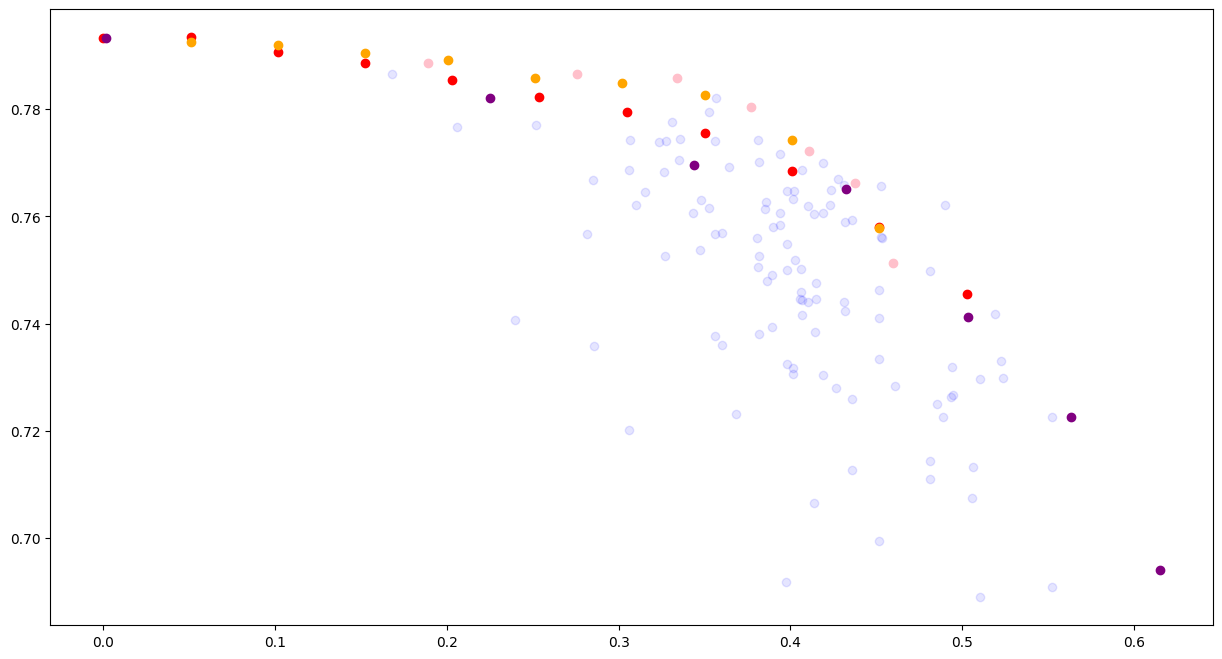

In [8]:
plt.figure(figsize=(15, 8))

# topk pruning
default_values = [[1.0]*12, [0.95]*12, [0.9]*12, [0.85]*12, [0.8]*12, [0.75]*12, [0.7]*12, [0.65]*12, [0.6]*12, [0.55]*12, [0.5]*12, [0.45]*12, [0.4]*12, [0.35]*12, [0.3]*12, [0.25]*12, [0.2]*12, [0.15]*12, [0.1]*12, [0.05]*12, [0.0]*12]
second_half_values = [[1.0]*6 + [0.9]*6, [1.0]*6 + [0.8]*6, [1.0]*6 + [0.7]*6, [1.0]*6 + [0.6]*6, [1.0]*6 + [0.5]*6, [1.0]*6 + [0.4]*6, [1.0]*6 + [0.3]*6, [1.0]*6 + [0.2]*6, [1.0]*6 + [0.1]*6, [1.0]*6 + [0.0]*6]
with open(f"../results/pruning_graphs/bias_topk.csv", mode='r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        threshold_list = ast.literal_eval(row["threshold"])
        threshold_list = [float(e) for e in threshold_list]
        alpha = 1.0
        if threshold_list in default_values:
            color = 'red'
        elif threshold_list in second_half_values:
            color = 'orange'
        else:
            color = 'blue'
            alpha = 0.1
        plt.scatter(float(row["pruned_ratio"]), float(row["accuracy"]), label=f"Threshold: {row['threshold_mean']}", c=color, alpha=alpha)

# score_threshold pruning
default_values = [[1.0]*12, [0.95]*12, [0.9]*12, [0.85]*12, [0.8]*12, [0.75]*12, [0.7]*12, [0.65]*12, [0.6]*12, [0.55]*12, [0.5]*12, [0.45]*12, [0.4]*12, [0.35]*12, [0.3]*12, [0.25]*12, [0.2]*12, [0.15]*12, [0.1]*12, [0.05]*12, [0.0]*12]
second_half_values = [[1.0]*6 + [0.9]*6, [1.0]*6 + [0.8]*6, [1.0]*6 + [0.7]*6, [1.0]*6 + [0.6]*6, [1.0]*6 + [0.5]*6, [1.0]*6 + [0.4]*6, [1.0]*6 + [0.3]*6, [1.0]*6 + [0.2]*6, [1.0]*6 + [0.1]*6, [1.0]*6 + [0.0]*6]
with open(f"../results/pruning_graphs/bias_score_threshold.csv", mode='r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        threshold_list = ast.literal_eval(row["threshold"])
        threshold_list = [float(e) for e in threshold_list]
        alpha = 1.0
        if threshold_list in default_values:
            color = 'purple'
        elif threshold_list in second_half_values:
            color = 'pink'
        else:
            color = 'cyan'
            alpha = 0.1
        plt.scatter(float(row["pruned_ratio"]), float(row["accuracy"]), label=f"Threshold: {row['threshold_mean']}", c=color, alpha=alpha)

plt.show()

In [9]:
params = SimpleNamespace(
    gpu_idx=1,
    num_classes=100,
    img_size=224,
    batch_size=128,
    checkpoint_path="../training_checkpoints/checkpoint1/vit_custom_epoch_200.pth",
    use_bias=True,
    bias_only=None,
    bias_topk=None,
    bias_score_threshold=None,
)

In [10]:
print("Number of visible GPUs :", torch.cuda.device_count())

torch.cuda.set_device(params.gpu_idx)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}:{torch.cuda.current_device()} {torch.cuda.get_device_name(torch.cuda.current_device())}" if torch.cuda.is_available() else "CPU")

Number of visible GPUs : 3
Device: cuda:1 NVIDIA GeForce RTX 2080 Ti


/tmp/ipykernel_1028992/1939274979.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(params.checkpoint_path, map_location=device)


Bias Only: [False, False, False, False, False, False, False, False, False, False, False, False], Accuracy: 0.7932, Top-5 Accuracy: 0.9224, Average Pruning Ratio: 0.0000


Bias Only: [False, False, False, False, False, False, False, False, False, False, True, True], Accuracy: 0.7880, Top-5 Accuracy: 0.9266, Average Pruning Ratio: 0.0000


Bias Only: [False, False, False, False, False, False, False, False, True, True, True, True], Accuracy: 0.7716, Top-5 Accuracy: 0.9162, Average Pruning Ratio: 0.0000


Bias Only: [False, False, False, False, False, False, True, True, True, True, True, True], Accuracy: 0.7474, Top-5 Accuracy: 0.8996, Average Pruning Ratio: 0.0000


Bias Only: [False, False, False, False, True, True, True, True, True, True, True, True], Accuracy: 0.6444, Top-5 Accuracy: 0.8408, Average Pruning Ratio: 0.0000


Bias Only: [False, False, True, True, True, True, True, True, True, True, True, True], Accuracy: 0.3094, Top-5 Accuracy: 0.5554, Average Pruning Ratio: 0.0000


Bias Only: [True, True, True, True, True, True, True, True, True, True, True, True], Accuracy: 0.1634, Top-5 Accuracy: 0.3714, Average Pruning Ratio: 0.0000


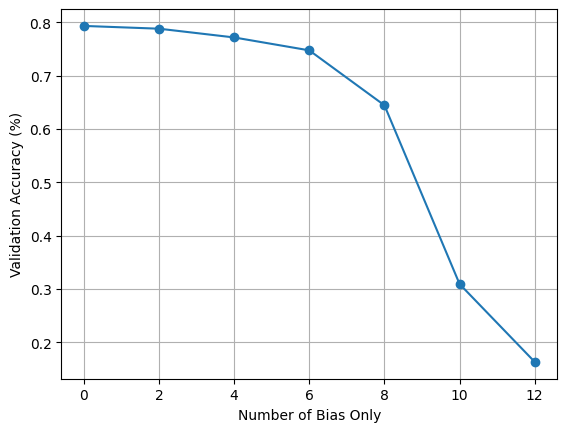

In [11]:
# plot accuracy en fonction du nombre de bias_only

_, val_loader, _, _ = get_data_loaders(batch_size=params.batch_size, persistent_workers=False, shuffle_val=True)

bias_only_values = [[False]*12, [False]*10 + [True]*2, [False]*8 + [True]*4, [False]*6 + [True]*6, [False]*4 + [True]*8, [False]*2 + [True]*10, [True]*12]
acc_values = []
avg_pruned_ratio_values = []

for bias_only in bias_only_values:
    model = custom_vit_s_16(num_classes=params.num_classes, image_size=params.img_size, use_bias=True, bias_only=bias_only, bias_topk=None, bias_score_threshold=None).to(device)
    checkpoint = torch.load(params.checkpoint_path, map_location=device)
    checkpoint = checkpoint["model_state_dict"]
    checkpoint = convert_qkv_to_q_k_v(checkpoint)
    model.load_state_dict(checkpoint)
    model.eval(); 

    avg_loss, avg_acc, avg_acc_top5, avg_pruned_ratio = val_one_epoch(val_loader, model, torch.nn.CrossEntropyLoss(), device, wandb_log=False)
    acc_values.append(avg_acc)
    avg_pruned_ratio_values.append(avg_pruned_ratio)
    print(f"Bias Only: {bias_only}, Accuracy: {avg_acc:.4f}, Top-5 Accuracy: {avg_acc_top5:.4f}, Average Pruning Ratio: {avg_pruned_ratio:.4f}")

plt.plot([sum(bias_only) for bias_only in bias_only_values], acc_values, marker='o')
plt.xlabel("Number of Bias Only")
plt.ylabel("Validation Accuracy (%)")
plt.xticks([sum(bias_only) for bias_only in bias_only_values])
plt.grid()
plt.show()